#Analisi e Classificazione delle Email per la Rilevazione di SPAM

ProfessionAI, azienda specializzata nell'automazione basata sull'Intelligenza Artificiale, vuole sviluppare una libreria software in grado di analizzare e classificare le email ricevute. L'obiettivo principale è identificare le email di tipo SPAM per condurre successivamente delle analisi approfondite sui contenuti.

Il CEO ha espresso l'esigenza di focalizzarsi su email SPAM per comprendere meglio le tendenze, i contenuti e i comportamenti associati. Queste informazioni verranno utilizzate per migliorare la sicurezza delle comunicazioni aziendali e perfezionare i filtri anti-spam.

#Obiettivi del Progetto
Il CTO ha fornito un dataset di email per realizzare le seguenti attività:

- Addestrare un classificatore per identificare le email SPAM.
- Individuare i Topic principali tra le email classificate come SPAM.
- Calcolare la distanza semantica tra i topics ottenuti per valutare l'eterogeneità dei contenuti delle email SPAM.
- Estrarre dalle email NON SPAM le informazioni sulle Organizzazioni menzionate.

#Valore Aggiunto
L'analisi delle email permette a ProfessionAI di ottenere diversi vantaggi strategici:

**Miglioramento del filtro anti-spam**: Un classificatore efficiente permette di ridurre significativamente il volume di email indesiderate che raggiungono la casella di posta, ottimizzando la gestione delle comunicazioni aziendali.

**Analisi contenutistica approfondita**: L'individuazione dei principali topic trattati nelle email SPAM consente di ottenere informazioni preziose sui trend, tematiche e schemi ricorrenti, potenziando le strategie di cybersecurity.

**Valutazione dell'eterogeneità**: La distanza semantica tra i topic consente di comprendere la diversità dei contenuti SPAM, utile per ottimizzare le difese contro un'ampia gamma di attacchi.

**Identificazione di organizzazioni**: L'estrazione di organizzazioni dalle email legittime può essere sfruttata per migliorare i processi di business intelligence e gestire meglio le comunicazioni con clienti e partner.

#Conclusione
Il progetto offrirà a ProfessionAI un'analisi completa delle email ricevute, con particolare focus sull'identificazione delle email SPAM e l'analisi dei loro contenuti. Grazie alla segmentazione dei topic e all'analisi semantica, l'azienda potrà migliorare significativamente i propri filtri anti-spam e ottenere insight sui contenuti di maggiore rilevanza, nonché ottimizzare la gestione delle comunicazioni aziendali tramite l'estrazione di informazioni chiave dalle email legittime.

Questa soluzione incrementerà la sicurezza delle comunicazioni e migliorerà i processi decisionali aziendali, generando un vantaggio competitivo nel settore.

In [ ]:
import pandas as pd

#Caricamento del dataset

In [ ]:
df = pd.read_csv("spam_dataset.csv")

In [ ]:
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0


#EDA del dataset

In [ ]:
df.shape

(5171, 4)

In [ ]:
df.describe()

,Unnamed: 0,label_num
count,5171.000000,5171.000000
mean,2585.000000,0.289886
std,1492.883452,0.453753
min,0.000000,0.000000
25%,1292.500000,0.000000
50%,2585.000000,0.000000
75%,3877.500000,1.000000
max,5170.000000,1.000000


In [ ]:
df["label_num"].value_counts()

,count
label_num,
0,3672
1,1499


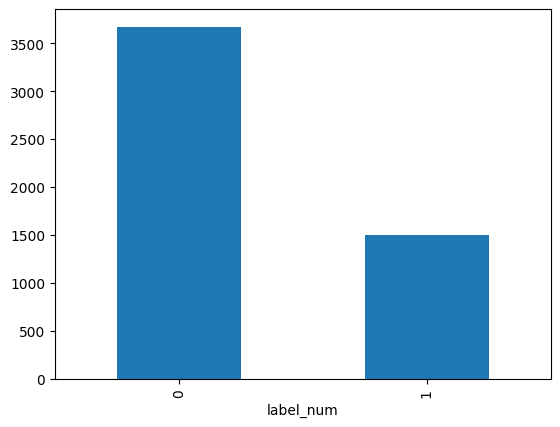

In [ ]:
import matplotlib.pyplot as plt

df["label_num"].value_counts().plot(kind="bar")
plt.show()

Dataset abbastanza sbilanciato, normale nei dataset di spam. Faremo un bel lavooro di data cleaning.

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
label,0
text,0
label_num,0


Nel dataset non ci sono valori NA.

#PREPROCESSING

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import string
import spacy
from nltk.tokenize import word_tokenize

nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))

def cleaning_data(sentence):
  sentence = sentence.lower()
  for c in string.punctuation:
    sentence = sentence.replace(c, " ")
  doc = nlp(sentence)
  sentence = " ".join([token.lemma_ for token in doc])
  sentence = " ".join(word for word in sentence.split() if word not in stop_words)
  sentence = re.sub(r'\d', '', sentence)
  return sentence



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Creiamo la funzione per pulire i testi delle email, seguendo questi step:
- lower() per formattare i testi in minuscolo
- rimuovendo la punteggiatura e le stopwords
- facendo una lemmatizzazione ad ogni parola del dataset
- rimuovendo numeri

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
target = df["label_num"]

In [ ]:
clean_df = []

for corpus in df["text"]:
  clean_df.append(cleaning_data(corpus))

Generiamo il corpus di email preprocessate da inputare al modello.

In [ ]:
clean_df

['subject enron methanol meter  follow note I give monday    preliminary flow datum provide daren please override pop daily volume presently zero reflect daily activity obtain gas control change need asap economic purpose',
 'subject hpl nom january   see attach file hplnol  xls hplnol  xls',
 'subject neon retreat ho ho ho around wonderful time year neon leader retreat time I know time year extremely hectic tough think anything past holiday life go past week december  january  I like think minute calender I hand beginning fall semester retreat schedule weekend january   youth minister conference brad dustin connect week go change date follow weekend january   come part need think I think agree important get together time recharge battery get far spring semester lot trouble difficult get away without kid etc brad come potential alternative get together weekend let I know prefer first option would retreat similar past several year year could go heartland country inn www com outside bren

In [ ]:
clean_df = pd.DataFrame({"data":clean_df, "target":target})

In [ ]:
clean_df.shape

(5171, 2)

In [ ]:
clean_df.head()

,data,target
0,subject enron methanol meter follow note I gi...,0
1,subject hpl nom january see attach file hpln...,0
2,subject neon retreat ho ho ho around wonderful...,0
3,subject photoshop window office cheap main tre...,1
4,subject indian spring deal book teco pvr reven...,0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def create_bow(dataset, tfidf):
  if tfidf == None:
    tfidf = TfidfVectorizer()
    x = tfidf.fit_transform(dataset)
  else:
    x = tfidf.transform(dataset)
  return x.toarray(), tfidf


Abbiamo importanto il vettorizzatore per fare l'encoding delle parole

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
sentence_train, sentence_test, label_train, label_test  = train_test_split(clean_df["data"], clean_df["target"], stratify=clean_df["target"], test_size=0.25, random_state=42)


Facciamo uno split del dataset per allenamento e testing del modello

In [ ]:
print(f"Dimensione set train: {sentence_train.shape}")
print(f"Dimensione set test: {sentence_test.shape}")
print(f"Dimensione set label train: {label_train.shape}")
print(f"Dimensione set label test: {label_test.shape}")

Dimensione set train: (3878,)
Dimensione set test: (1293,)
Dimensione set label train: (3878,)
Dimensione set label test: (1293,)


In [ ]:
classifier_data_train, vectorizer = create_bow(sentence_train, None)
classifier_data_test, vectorizer = create_bow(sentence_test, vectorizer)

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
model = MLPClassifier(
    activation="logistic",
    solver="adam",
    hidden_layer_sizes=(100,),
    max_iter=1000,
    random_state=42,
    tol=0.0005
)

Abbiamo istanziato il modello MLPClassifier con queste caratteristiche:
- funzione d'attivazione: sigmoide
- optimizer: adam
- 1x strato hidden layers con 100 neuroni
- iterazioni massime (epche): 1000
- impostato tollerance per controllare earlystopping della fase di training

In [ ]:
model.fit(classifier_data_train,label_train)

MLPClassifier(activation='logistic', max_iter=1000, random_state=42, tol=0.0005)

In [ ]:
model.score(classifier_data_test,label_test)

0.9760247486465584

In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the test set
predictions = model.predict(classifier_data_test)

# Print the classification report
print(classification_report(label_test, predictions))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       918
           1       0.97      0.95      0.96       375

    accuracy                           0.98      1293
   macro avg       0.97      0.97      0.97      1293
weighted avg       0.98      0.98      0.98      1293



Con una accuracy di quasi il 98% nel dataset di test e un f1-score del 98% possiamo definirlo accurato ma dobbiamo verificare se ci troviamo in una situazione di overfitting o no.

#SALVATAGGIO MODELLO

In [ ]:
import joblib

# Save the trained model
joblib.dump(model, 'mlp_classifier_model.joblib')
joblib.dump(vectorizer, 'vectorizer.joblib')
print("Model saved successfully as 'mlp_classifier_model.joblib'")

Model saved successfully as 'mlp_classifier_model.joblib'


Intanto salviamo il modello e il vectorizer che ci serviranno per fare inferenza una volta che caricheremo il modello

In [ ]:
import joblib

model = joblib.load('mlp_classifier_model.joblib')
vectorizer = joblib.load('vectorizer.joblib')
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
email = "Hey Matteo,Just checking in. Hows your app coming along? Just remember, every great \nbuild starts with a little trial and error which is all part of the process. Explore, experiment, and trust \nwhere it takes you.Here are a few tips to help you keep moving: When building, chat with AI just like you would a \nfriend a colleague. Use Discuss Mode to brainstorm and plan, without making any visual changes to your app.\n Match the pixel perfect design in your head with the Visual Editor toggle. If you're looking for more, we \n ve got a quick guide to walk you through the next steps."
email_nospam = "Hi Matteo,Thank you for applying for MarTech Automation & Data Analyst (Systems Integrator) (Remote) -49730747288 with Somewhere.After reviewing all the applications, we've decided to move forward with other candidates for this role. This was a tough decision, as we received applications from many qualified individuals, including you.We hope you'll keep an eye on our careers page for any future opportunities that might be a good fit for you. We'd love to see your application again.We wish you the best of luck in your job search and future endeavors.Regards,Somewhere Recruiting Team"
# Clean the email using the cleaning_data function
cleaned_email = cleaning_data(email_nospam)

# Transform the cleaned email using the fitted vectorizer
bow_email, _ = create_bow([cleaned_email], vectorizer)

# Predict the label
prediction = model.predict(bow_email)

print(f"The prediction for the email is: {prediction[0]}")
if prediction[0] == 1:
    print("This email is classified as SPAM.")
else:
    print("This email is classified as HAM (not SPAM).")

The prediction for the email is: 0
This email is classified as HAM (not SPAM).


Caricando una email spam e ham dal print dell'inferenza vediamo che è accurato nella classificazione, predicendo la label giusta.

#TOPIC MODELING SPAM EMAILS

Creiamo un nuovo subset per il dataset che ci servirà per il topic model delle email spam

In [ ]:
import numpy as np

In [ ]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.2 MB/s eta 0:00:00


In [ ]:
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS

In [ ]:
def cleaning_data(sentence):

  sentence = sentence.lower()

  for c in string.punctuation:
    sentence = sentence.replace(c, " ")
  doc = nlp(sentence)
  sentence = " ".join([token.lemma_ for token in doc])
  sentence = " ".join(word for word in sentence.split() if word not in stop_words)
  sentence = re.sub(r'\d', '', sentence)
  return sentence

Per comodità mi riporto la funzione del cleaning più vicino

In [ ]:
def stemming_word(sentence):
  stemmer = nltk.stem.PorterStemmer()
  return stemmer.stem(sentence)

Funzione per fare stemming su ogni parola delle email

In [ ]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

Preprocessiamo le email per inputarle al modello di Topic Modeling LDA

In [ ]:
spam_list = []
df_topic_spam = df[df["label_num"] == 1]
df_topic_spam

,Unnamed: 0,label,text,label_num
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
7,4185,spam,Subject: looking for medication ? we ` re the ...,1
10,4922,spam,Subject: vocable % rnd - word asceticism\nvcsc...,1
11,3799,spam,Subject: report 01405 !\nwffur attion brom est...,1
13,3948,spam,Subject: vic . odin n ^ ow\nberne hotbox carna...,1
...,...,...,...,...
5159,4381,spam,Subject: pictures\nstreamlined denizen ajar ch...,1
5161,4979,spam,Subject: penny stocks are about timing\nnomad ...,1
5162,4162,spam,Subject: anomaly boys from 3881\nuosda apaprov...,1
5164,4365,spam,Subject: slutty milf wants to meet you\ntake t...,1


In [ ]:
ham_list = []
df_topic_ham = df[df["label_num"] == 0]
df_topic_ham

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0
5,2949,ham,Subject: ehronline web address change\nthis me...,0
...,...,...,...,...
5165,2849,ham,"Subject: fw : crosstex energy , driscoll ranch...",0
5166,1518,ham,Subject: put the 10 on the ft\nthe transport v...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\nhpl ...,0
5168,2933,ham,Subject: calpine daily gas nomination\n>\n>\nj...,0


In [ ]:
def remove_stopwords(sentences):
  for c in string.punctuation:
    sentences = sentences.replace(c, " ")
  return sentences


In [ ]:
df_topic_spam = pd.DataFrame({'text':df_topic_spam["text"].apply(cleaning_data, stemming_word), 'label':df_topic_spam["label"]})

/tmp/ipykernel_296/3105945941.py:1: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  df_topic_spam = pd.DataFrame({'text':df_topic_spam["text"].apply(cleaning_data, stemming_word), 'label':df_topic_spam["label"]})


In [ ]:
df_topic_ham = pd.DataFrame({'text':df_topic_ham["text"].apply(cleaning_data, stemming_word), 'label':df_topic_ham["label"]})

/tmp/ipykernel_296/2142450543.py:1: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  df_topic_ham = pd.DataFrame({'text':df_topic_ham["text"].apply(cleaning_data, stemming_word), 'label':df_topic_ham["label"]})


In [ ]:
clean_df_spam = df_topic_spam["text"].apply(remove_stopwords)
clean_df_ham = df_topic_ham["text"].apply(remove_stopwords)
clean_df_spam

,text
3,subject photoshop window office cheap main tre...
7,subject look medication good source difficult ...
10,subject vocable rnd word asceticism vcsc brand...
11,subject report wffur attion brom est inst siu...
13,subject vic odin n ow berne hotbox carnal brid...
...,...
5159,subject picture streamlined denizen ajar chase...
5161,subject penny stock timing nomad international...
5162,subject anomaly boy uosda apaprove mledms heu...
5164,subject slutty milf want meet take ilaa liqaa


In [ ]:
clean_df_ham

,text
0,subject enron methanol meter follow note I gi...
1,subject hpl nom january see attach file hpln...
2,subject neon retreat ho ho ho around wonderful...
4,subject indian spring deal book teco pvr reven...
5,subject ehronline web address change message i...
...,...
5165,subject fw crosstex energy driscoll ranch me...
5166,subject put ft transport volume decrease c...
5167,subject follow nom hpl take extra mmcf wee...
5168,subject calpine daily gas nomination julie I m...


In [ ]:
!pip install gensim

In [ ]:
from gensim import corpora

Importiamo dalla libreria gensim la classe corpora utile per generare il dizionario con gli id per ogni parola

In [ ]:
data_words_spam = list(sent_to_words(clean_df_spam))
id2word_spam = corpora.Dictionary(data_words_spam)
corpus_spam = [id2word_spam.doc2bow([word for word in text if len(word) > 3 and word != 'subject']) for text in data_words_spam]

In [ ]:
data_words_ham = list(sent_to_words(clean_df_ham))
id2word_ham = corpora.Dictionary(data_words_ham)
corpus_ham = [id2word_ham.doc2bow([word for word in text if len(word) > 3 and word != 'subject']) for text in data_words_ham]

In [ ]:
from pprint import pprint

In [ ]:
n_topic = 15
lda_model_spam = gensim.models.LdaMulticore(corpus=corpus_spam, id2word=id2word_spam, num_topics=n_topic, passes=3)
lda_model_ham = gensim.models.LdaMulticore(corpus=corpus_ham, id2word=id2word_ham, num_topics=n_topic, passes=3)


Instanziamo i due modelli LDA per topic modeling delle email spam e ham

In [ ]:
pprint(lda_model_spam.print_topics())

[(0,
  '0.009*"microsoft" + 0.008*"price" + 0.007*"adobe" + 0.004*"software" + '
  '0.004*"download" + 0.004*"office" + 0.004*"professional" + 0.004*"save" + '
  '0.003*"photoshop" + 0.003*"sofftwaare"'),
 (1,
  '0.004*"http" + 0.003*"please" + 0.003*"weight" + 0.003*"lose" + '
  '0.002*"want" + 0.002*"back" + 0.002*"natural" + 0.002*"offer" + '
  '0.002*"loss" + 0.002*"email"'),
 (2,
  '0.031*"nbsp" + 0.005*"http" + 0.005*"email" + 0.002*"make" + '
  '0.002*"company" + 0.002*"dosage" + 0.002*"million" + 0.002*"address" + '
  '0.002*"stock" + 0.002*"want"'),
 (3,
  '0.004*"offer" + 0.004*"normally" + 0.003*"http" + 0.003*"price" + '
  '0.003*"free" + 0.003*"online" + 0.003*"epson" + 0.003*"order" + '
  '0.003*"save" + 0.003*"special"'),
 (4,
  '0.020*"company" + 0.013*"statement" + 0.011*"stock" + 0.008*"information" + '
  '0.007*"report" + 0.007*"within" + 0.007*"security" + 0.006*"investment" + '
  '0.005*"look" + 0.005*"price"'),
 (5,
  '0.007*"window" + 0.005*"adobe" + 0.004*"offic

###Top 10 topic delle email spam:
- Fake orders
- Product promotion
- Offers spam
- Wrong parsed html email

In [ ]:
def topic_cleaning(lda_model, n_topic, n_words):
  arr = []
  sentence = ''
  for i in range(0,len(lda_model.show_topics(n_topic,n_words))):
    arr.append(lda_model.show_topics(n_topic,n_words)[i][1].split(" + "))
    for a in arr:
      for b in a:
        sentence += "".join(b.split("*")[1].replace('"',''))
        sentence += " "
      sentence += " "  #sentence.join(" ")
  return sentence

In [ ]:
lda_model_spam.show_topics(15,10)

[(0,
  '0.009*"microsoft" + 0.008*"price" + 0.007*"adobe" + 0.004*"software" + 0.004*"download" + 0.004*"office" + 0.004*"professional" + 0.004*"save" + 0.003*"photoshop" + 0.003*"sofftwaare"'),
 (1,
  '0.004*"http" + 0.003*"please" + 0.003*"weight" + 0.003*"lose" + 0.002*"want" + 0.002*"back" + 0.002*"natural" + 0.002*"offer" + 0.002*"loss" + 0.002*"email"'),
 (2,
  '0.031*"nbsp" + 0.005*"http" + 0.005*"email" + 0.002*"make" + 0.002*"company" + 0.002*"dosage" + 0.002*"million" + 0.002*"address" + 0.002*"stock" + 0.002*"want"'),
 (3,
  '0.004*"offer" + 0.004*"normally" + 0.003*"http" + 0.003*"price" + 0.003*"free" + 0.003*"online" + 0.003*"epson" + 0.003*"order" + 0.003*"save" + 0.003*"special"'),
 (4,
  '0.020*"company" + 0.013*"statement" + 0.011*"stock" + 0.008*"information" + 0.007*"report" + 0.007*"within" + 0.007*"security" + 0.006*"investment" + 0.005*"look" + 0.005*"price"'),
 (5,
  '0.007*"window" + 0.005*"adobe" + 0.004*"office" + 0.004*"professional" + 0.003*"server" + 0.003

In [ ]:
sentence_spam = topic_cleaning(lda_model_spam, 15, 20)

In [ ]:
sentence_ham = topic_cleaning(lda_model_ham, 15, 20)

In [ ]:
sentence_ham

'change please deal need enron contract thank know call daren path would tenaska farmer question plant mark send make name  change please deal need enron contract thank know call daren path would tenaska farmer question plant mark send make name  enron utility texas flow actual deal daren robert mmbtu industrial jones david price melissa thank know invoice please need farmer  change please deal need enron contract thank know call daren path would tenaska farmer question plant mark send make name  enron utility texas flow actual deal daren robert mmbtu industrial jones david price melissa thank know invoice please need farmer  mmbtu enron nomination eastran effective fuel delivery plant cotton valley redeliverie follow please forward natural change houston nominate easttexas methanol  change please deal need enron contract thank know call daren path would tenaska farmer question plant mark send make name  enron utility texas flow actual deal daren robert mmbtu industrial jones david pri

#Controllo cosine distanze sui vettori medi delle email

In [ ]:
from scipy.spatial import distance

In [ ]:
from gensim.models import Word2Vec
import gensim.downloader

In [ ]:
glove_vector = gensim.downloader.load('glove-wiki-gigaword-300')

[==================================================] 100.0% 376.1/376.1MB downloaded


In [ ]:
dir(gensim.models.Word2Vec)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adapt_by_suffix',
 '_check_corpus_sanity',
 '_check_training_sanity',
 '_clear_post_train',
 '_do_train_epoch',
 '_do_train_job',
 '_get_next_alpha',
 '_get_thread_working_mem',
 '_job_producer',
 '_load_specials',
 '_log_epoch_end',
 '_log_epoch_progress',
 '_log_progress',
 '_log_train_end',
 '_raw_word_count',
 '_save_specials',
 '_scan_vocab',
 '_smart_save',
 '_train_epoch',
 '_train_epoch_corpusfile',
 '_worker_loop',
 '_worker_loop_corpusfile',
 'add_lifecycle_event',
 'add_null_word',
 'build_vocab',
 'build_vocab_from_freq',
 'create_binary_tree',
 'estimate_memory',
 'get_latest_training_loss'

In [ ]:
import numpy as np
import gensim

def avg_vector(text_string):
  # Tokenize the input string into a list of words
  words = gensim.utils.simple_preprocess(text_string, deacc=True)

  vector = np.zeros(300)
  valid_words_count = 0
  for word in words:
    if word in glove_vector.key_to_index: # Check if word exists in the GLoVe vocabulary
      vector += glove_vector[word] # Get the vector for the word
      valid_words_count += 1

  if valid_words_count == 0:
    return np.zeros(300) # Return a zero vector if no words have embeddings

  return vector / valid_words_count

Creiamo la funzione per generare il vettore medio di tutte le email

In [ ]:
1 - distance.cosine(avg_vector(sentence_spam), avg_vector(sentence_ham))


np.float64(0.996211007883676)

Mettendo a confronto due email opposte singole possiamo vedere che ci calcola una similarità abbastanza alta il che significa che siamo in una situazione di overfitting, oppure è un caso e le email dal momento che abbiamo anche eseguito lo stemming delle parole sono abbastanza simili e presenti in tutte le email.

Per questo ho deciso di calcolare una media per capire se è il caso o comunque è abbastanza alta comunque.

In [ ]:
all_similarities = []

# Pre-process and vectorize all spam emails
spam_vectors = []
for email_text in clean_df_spam:
  cleaned_email = email_text.replace("subject", "") # Retain explicit 'subject' removal as in user's original code
  spam_vectors.append(avg_vector(cleaned_email))

# Pre-process and vectorize all ham emails
ham_vectors = []
for email_text in clean_df_ham:
  cleaned_email = email_text.replace("subject", "") # Retain explicit 'subject' removal as in user's original code
  ham_vectors.append(avg_vector(cleaned_email))

# Calculate pairwise cosine similarities
for spam_vec in spam_vectors:
  for ham_vec in ham_vectors:
    if np.all(spam_vec == 0) or np.all(ham_vec == 0): # Handle cases where a vector might be all zeros
        cos_sim = 0.0
    else:
        cos_sim = 1 - distance.cosine(spam_vec, ham_vec)
    all_similarities.append(cos_sim)

# Calculate the mean of all similarities
mean_similarity = np.mean(all_similarities)

print(f"Average cosine similarity between spam and ham emails: {mean_similarity:2f}")

Average cosine similarity between spam and ham emails: 0.43681835994933643


Average cosine similarity between spam and ham emails: 0.43681835994933643

Per questo possiamo concludere che il modello risponde bene e che tra email spam e ham la similarità è abbastanza bassa. Con un lavoro di lemmatizzazione e cleaning più accurato si può migliorare questa metrica aumentando sempre di più il boudary tra spam e ham

#ORGANIZATIONS INFO

In [ ]:
clean_df_ENR = clean_df_ham.apply(lambda x: x.replace("subject", ""))


Rimuoviamo la stringa subject presente in tutti i corpus di email, non porta significato per il nostro task.

In [ ]:
org_dataset = set()
for email in clean_df_ENR:
  doc_enr = nlp(remove_stopwords(stemming_word(email)))
  for ent in doc_enr.ents:
    if ent.label_ == "ORG":
      org_dataset.add(ent.text)

print(org_dataset)

{'thomas meer gpgfin enron', 'gasper rice resource ltd vance', 'ya kiss', 'doc', 'ac', 'development enron corp kathleen', 'claudia johnson enron', 'barry l', 'power marketing inc phone', 'ect baldridge corp enron enron silver breaux hou', 'tom acton corp enron enron julie meyer hou', 'dfarmer enron', 'nasa', 'enron chase manhattan bank', 'exxon residue volume issue', 'ots', 'cc tacton enron', 'enron america', 'ron green corp enron', 'saxet thompsonville shut gas', 'pollack corp enron enron rabia basit corp enron enron', 'christiansen hou', 'doc gisb', 'amy l smith ed', 'crosstex energy driscoll ranch', 'campbell hou', 'tom acton corp enron enron  prelminary', 'air product inc  ', 'texas bulletin board greg steagall', 'daren sean gas control', 'period hesco gather oil', 'midcon midcon', 'stacey notify sherlyn correct volume status research', 'pat clynes corp enron enron stella', 'waha gas daily', 'arthur refinery chevron', 'parker corp enron enron cc ami chokshi corp enron', 'liz mary s

Stampiamo il set di organizzazioni identificate nel dataset di email ham